In [2]:
import pandas as pd

# TP 1  - Étude préliminaire

## Chargement

In [3]:
analyse_file = "analyses_2022.csv.zst"

analyse_df_sample = pd.read_csv(analyse_file, sep=";", nrows=1)

categorical_values = ("Lb", "Nom", "Mnemo", "Cd", "Sym", "Com")
categories = analyse_df_sample.columns[analyse_df_sample.columns.str.startswith(categorical_values)]

dict_categories = {col: "category" for col in categories}
dict_converters = {col: str for col in categories}
chunksize = 500_000

iterator = pd.read_csv(analyse_file, 
                       sep=";", 
                       na_values="",
                       escapechar="\\",
                       converters=dict_converters,
                       dtype = {'RsAna':'str'},
                       parse_dates=['DatePrel'],
                       chunksize=chunksize)
iterator

analyse_df = None
i=0
for df in iterator:
    print(i)
    i+=chunksize
    df = df.astype(dtype=dict_categories)
    #on enlève la teinte de l'eau (1739) et l'odeur (1416) qui donnent un résultat en chaine de caractère
    cond_remove_teinte = df.CdParametre!='1739'
    cond_remove_odeur = df.CdParametre!='1416'
    df = df[cond_remove_teinte & cond_remove_odeur].astype({'RsAna':'float64'})
    if analyse_df is None:
        analyse_df = df
    else:
        for col in dict_categories:
            cat_union = analyse_df[col].cat.categories.union(df[col].cat.categories);
            analyse_df[col]=analyse_df[col].cat.set_categories(cat_union)
            df[col]=df[col].cat.set_categories(cat_union)
        analyse_df= pd.concat([analyse_df,df],ignore_index=True)

analyse_df

0
500000
1000000
1500000
2000000
2500000
3000000
3500000
4000000
4500000
5000000
5500000
6000000


/tmp/ipykernel_11129/1606182481.py:24: DtypeWarning: Columns (0: HeureAna) have mixed types. Specify dtype option on import or set low_memory=False.
  for df in iterator:


6500000


/tmp/ipykernel_11129/1606182481.py:24: DtypeWarning: Columns (0: HeureAna) have mixed types. Specify dtype option on import or set low_memory=False.
  for df in iterator:


7000000


/tmp/ipykernel_11129/1606182481.py:24: DtypeWarning: Columns (0: HeureAna) have mixed types. Specify dtype option on import or set low_memory=False.
  for df in iterator:


7500000


/tmp/ipykernel_11129/1606182481.py:24: DtypeWarning: Columns (0: HeureAna) have mixed types. Specify dtype option on import or set low_memory=False.
  for df in iterator:


8000000
8500000


,CdStationMesureEauxSurface,LbStationMesureEauxSurface,CdSupport,LbSupport,CdFractionAnalysee,LbFractionAnalysee,CdPrelevement,DatePrel,HeurePrel,DateAna,...,CommentairesAna,ComResultatAna,CdRdd,NomRdd,CdProducteur,NomProducteur,CdPreleveur,NomPreleveur,CdLaboratoire,NomLaboratoire
0,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,10:10:00,NaN,...,,,0101320161,Réseau de suivi local de l’opération de restau...,18591178100028,AGENCE DE L EAU ARTOIS PICARDIE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
1,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,10:10:00,NaN,...,,,0101320161,Réseau de suivi local de l’opération de restau...,18591178100028,AGENCE DE L EAU ARTOIS PICARDIE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
2,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,10:10:00,NaN,...,,,0101320161,Réseau de suivi local de l’opération de restau...,18591178100028,AGENCE DE L EAU ARTOIS PICARDIE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
3,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,10:10:00,NaN,...,,,0101320161,Réseau de suivi local de l’opération de restau...,18591178100028,AGENCE DE L EAU ARTOIS PICARDIE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
4,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,10:10:00,NaN,...,,,0101320161,Réseau de suivi local de l’opération de restau...,18591178100028,AGENCE DE L EAU ARTOIS PICARDIE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8790163,06133330,DORON DE CHAMPAGNY A CHAMPAGNY-EN-VANOISE 2,3,Eau,3,"Phase aqueuse de l'eau (filtrée, centrifugée...)",778243,2022-10-25,15:22:00,2022-10-26,...,,,0600000261/0600000275,,18690155900069,AGENCE EAU RHONE MEDITERRANEE ET CORSE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
8790164,06133330,DORON DE CHAMPAGNY A CHAMPAGNY-EN-VANOISE 2,3,Eau,3,"Phase aqueuse de l'eau (filtrée, centrifugée...)",778243,2022-10-25,15:22:00,2022-10-26,...,,,0600000261/0600000275,,18690155900069,AGENCE EAU RHONE MEDITERRANEE ET CORSE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
8790165,06133330,DORON DE CHAMPAGNY A CHAMPAGNY-EN-VANOISE 2,3,Eau,3,"Phase aqueuse de l'eau (filtrée, centrifugée...)",778243,2022-10-25,15:22:00,2022-10-26,...,,,0600000261/0600000275,,18690155900069,AGENCE EAU RHONE MEDITERRANEE ET CORSE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...
8790166,06133330,DORON DE CHAMPAGNY A CHAMPAGNY-EN-VANOISE 2,3,Eau,3,"Phase aqueuse de l'eau (filtrée, centrifugée...)",778243,2022-10-25,15:22:00,2022-10-26,...,,,0600000261/0600000275,,18690155900069,AGENCE EAU RHONE MEDITERRANEE ET CORSE,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...,41054531300042,CARSO - LABORATOIRE SANTE ENVIRONNEMENT HYGIEN...


## Étude des données brutes

### Sélection des informations utiles

Quelles colonnes garder ?

- Colonnes suffisamment complètes
- Colonnes en lien avec notre objectif : on cherche à analyser les **résultats d'analyse** par **Station** et **Prélèvement** (par **date**). Un résultat se caractérise par une **valeur**, un **paramètre physico-chimique**, une **fraction** et une **unité de mesure**

In [4]:
analyse_df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 8790168 entries, 0 to 8790167
Data columns (total 51 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   CdStationMesureEauxSurface  8790168 non-null  category      
 1   LbStationMesureEauxSurface  8790168 non-null  category      
 2   CdSupport                   8790168 non-null  category      
 3   LbSupport                   8790168 non-null  category      
 4   CdFractionAnalysee          8790168 non-null  category      
 5   LbFractionAnalysee          8790168 non-null  category      
 6   CdPrelevement               8790168 non-null  category      
 7   DatePrel                    8790168 non-null  datetime64[us]
 8   HeurePrel                   8790168 non-null  str           
 9   DateAna                     8307222 non-null  str           
 10  HeureAna                    5774832 non-null  object        
 11  CdParametre                 8790168

In [5]:
analyse_df_slim = analyse_df.iloc[:,list(range(0,8))+list(range(11,18))+[23,24]]
analyse_df_slim.info()

<class 'pandas.DataFrame'>
RangeIndex: 8790168 entries, 0 to 8790167
Data columns (total 17 columns):
 #   Column                      Dtype         
---  ------                      -----         
 0   CdStationMesureEauxSurface  category      
 1   LbStationMesureEauxSurface  category      
 2   CdSupport                   category      
 3   LbSupport                   category      
 4   CdFractionAnalysee          category      
 5   LbFractionAnalysee          category      
 6   CdPrelevement               category      
 7   DatePrel                    datetime64[us]
 8   CdParametre                 category      
 9   LbLongParamètre             category      
 10  RsAna                       float64       
 11  CdUniteMesure               category      
 12  SymUniteMesure              category      
 13  CdRqAna                     category      
 14  MnemoRqAna                  category      
 15  LdAna                       float64       
 16  LqAna                       f

## Statistiques descriptives

### Description des différentes colonnes

In [6]:
analyse_df_slim.describe()

,DatePrel,RsAna,LdAna,LqAna
count,8790168,8.298011e+06,7.881188e+06,8.306880e+06
mean,2022-06-03 22:34:42.573712,1.671978e+01,1.196799e+00,3.468330e+00
min,2022-01-01 00:00:00,0.000000e+00,-2.000000e+01,-2.000000e+01
25%,2022-03-16 00:00:00,5.000000e-03,1.700000e-03,5.000000e-03
50%,2022-05-19 00:00:00,2.000000e-02,7.000000e-03,2.000000e-02
75%,2022-08-11 00:00:00,2.500000e-02,7.000000e-03,2.000000e-02
max,2022-12-30 00:00:00,1.337750e+07,1.670000e+04,5.000000e+04
std,NaN,7.627338e+03,3.704156e+01,1.134691e+02


### Description des différents paramètres physico-chimiques
Les paramètres physico-chimiques étant très nombreux, on va tout d'abord se limiter aux plus fréquents

In [7]:
specif_param = analyse_df_slim['LbLongParamètre'] \
                .str.cat(analyse_df_slim['LbFractionAnalysee'],sep=' - ') \
                .str.cat(analyse_df_slim['SymUniteMesure'],sep=' - ') \
                .astype('category')

specif_param 

0          Turbidité Formazine Néphélométrique - Eau brut...
1                      Température de l'Eau - Eau brute - °C
2          Potentiel en Hydrogène (pH) - Eau brute - unit...
3                    Conductivité à 25°C - Eau brute - µS/cm
4                     Oxygène dissous - Eau brute - mg(O2)/L
                                 ...                        
8790163    Titre alcalimétrique complet (T.A.C.) - Phase ...
8790164    Potassium - Phase aqueuse de l'eau (filtrée, c...
8790165    Magnésium - Phase aqueuse de l'eau (filtrée, c...
8790166    Calcium - Phase aqueuse de l'eau (filtrée, cen...
8790167    Sodium - Phase aqueuse de l'eau (filtrée, cent...
Name: LbLongParamètre, Length: 8790168, dtype: category
Categories (5124, str): ['1,1,1,2-Tetrachloropropane - Particule < 2 mm..., '1,1,1,2-Tetrachloropropane - Particule < 2 mm..., '1,1,1,3-Tetrachloropropane - Particule < 2 mm..., '1,1,1,3-Tetrachloropropane - Particule < 2 mm..., ..., 'tétrabromodiphényl éther (congénère 47

In [8]:
analyse_df_slim['param_frac_unit'] = specif_param

In [9]:
frequent_parameters = analyse_df_slim['param_frac_unit'] \
                        .groupby(analyse_df_slim['param_frac_unit']) \
                        .count() \
                        .sort_values(ascending=False) \
                        .head(30)
frequent_parameters

param_frac_unit
Température de l'Eau - Eau brute - °C                                                            26468
Potentiel en Hydrogène (pH) - Eau brute - unité pH                                               26359
Oxygène dissous - Eau brute - mg(O2)/L                                                           26298
Conductivité à 25°C - Eau brute - µS/cm                                                          26216
Taux de saturation en oxygène - Eau brute - %                                                    26141
Matières en suspension - Eau brute - mg/L                                                        22262
Turbidité Formazine Néphélométrique - Eau brute - NFU                                            21923
Carbone Organique - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(C)/L                   21821
Nitrates - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NO3)/L                          21734
Phosphore total - Eau brute - mg(P)/L                    

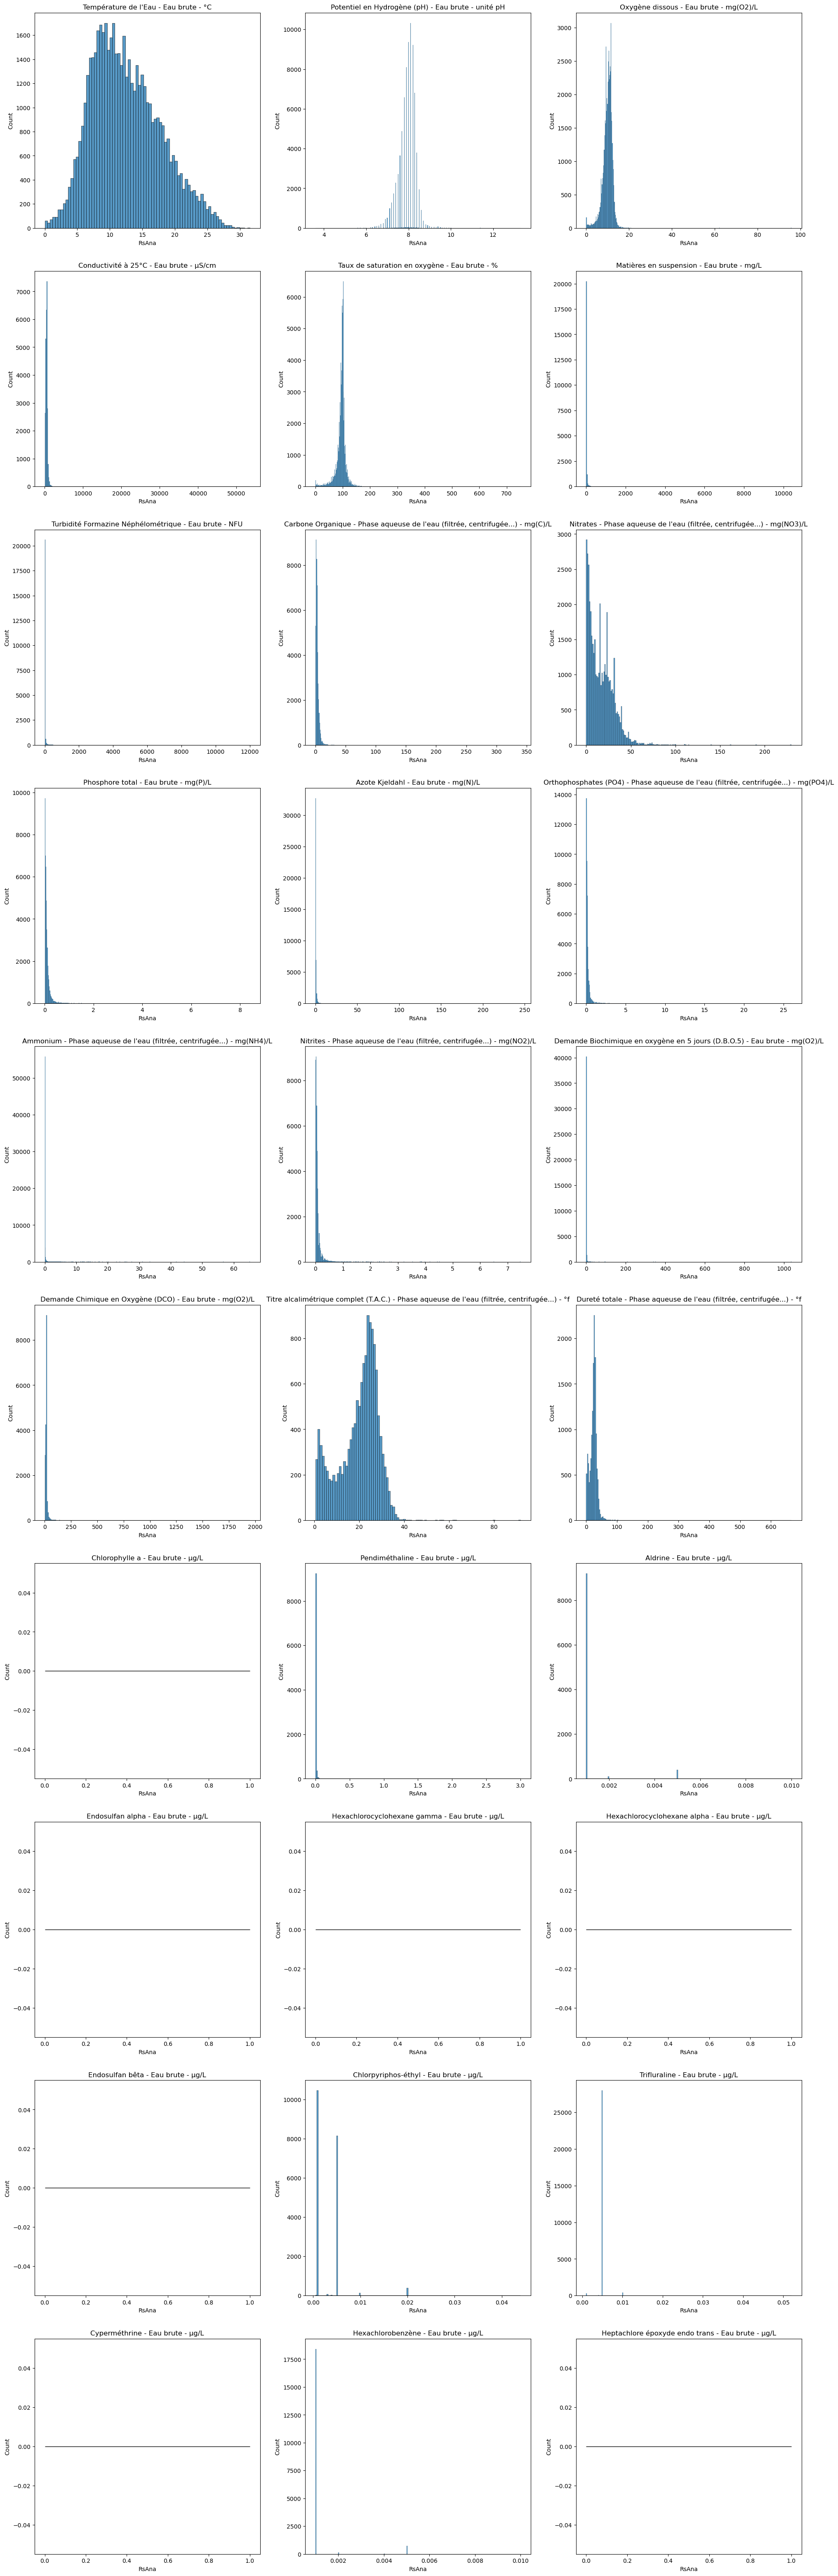

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
ncols = 3
nrows = len(frequent_parameters)//ncols + ((len(frequent_parameters)%ncols)!=0) 

fig,axs = plt.subplots(nrows,ncols,figsize = (ncols*8,nrows*8))
r,c=0,0
for param in frequent_parameters.index:
    
    df_fp = analyse_merged[analyse_merged['param_frac_unit'] == param]
    g = sns.histplot(
        data = df_fp,
        x = "RsAna",
        ax = axs[c][r]
        ).set(title=param)
    
    r=(r+1)%ncols
    c += (r==0)


### Étude de la répartition par rapport aux classes de qualité

In [46]:
#Chargement du fichier du seq eau

seq_eau = pd.read_csv("classe_alteration_seq_eau.csv",
                      na_values="\\N",
                      true_values=['t'],
                      false_values=['f'],
                      dtype={"parametre_id" :"str",'parametre_nom':'category','alteration_nom':'category','libelle':'category'}).astype({'parametre_id':'category'})
seq_eau

,id,parametre_id,parametre_nom,alteration_id,alteration_nom,valeur,libelle,borne_inf_incluse,borne_sup_incluse,borne_inf,borne_sup,unite_mesure_code
0,10231,1301,Température de l'Eau,0,TEMP,1,Bleu,True,False,NaN,24.0,27
1,10232,1301,Température de l'Eau,0,TEMP,2,Vert,True,False,24.0,25.5,27
2,10233,1301,Température de l'Eau,0,TEMP,3,Jaune,True,False,25.5,27.0,27
3,10234,1301,Température de l'Eau,0,TEMP,4,Orange,True,False,27.0,28.0,27
4,10235,1301,Température de l'Eau,0,TEMP,5,Rouge,True,False,28.0,NaN,27
...,...,...,...,...,...,...,...,...,...,...,...,...
1096,10659,1383,Zinc,16,MPMI,2,Vert,True,False,1.4,14.0,133
1097,10660,1383,Zinc,16,MPMI,3,Jaune,True,False,14.0,140.0,133
1098,10661,1383,Zinc,16,MPMI,4,Orange,True,False,140.0,330.0,133
1099,10662,1383,Zinc,16,MPMI,5,Rouge,True,False,330.0,NaN,133


In [12]:
analyse_merged = analyse_df_slim.merge(seq_eau,left_on="CdParametre",right_on="parametre_id")

cond_inf = analyse_merged.borne_inf.isna() | (analyse_merged.borne_inf_incluse & (analyse_merged.borne_inf <=  analyse_merged.RsAna)) | (analyse_merged.borne_inf < analyse_merged.RsAna)
cond_sup = analyse_merged.borne_sup.isna() | (analyse_merged.borne_sup_incluse & (analyse_merged.borne_sup >=  analyse_merged.RsAna)) | (analyse_merged.borne_sup > analyse_merged.RsAna)
analyse_merged = analyse_merged[cond_inf & cond_sup]

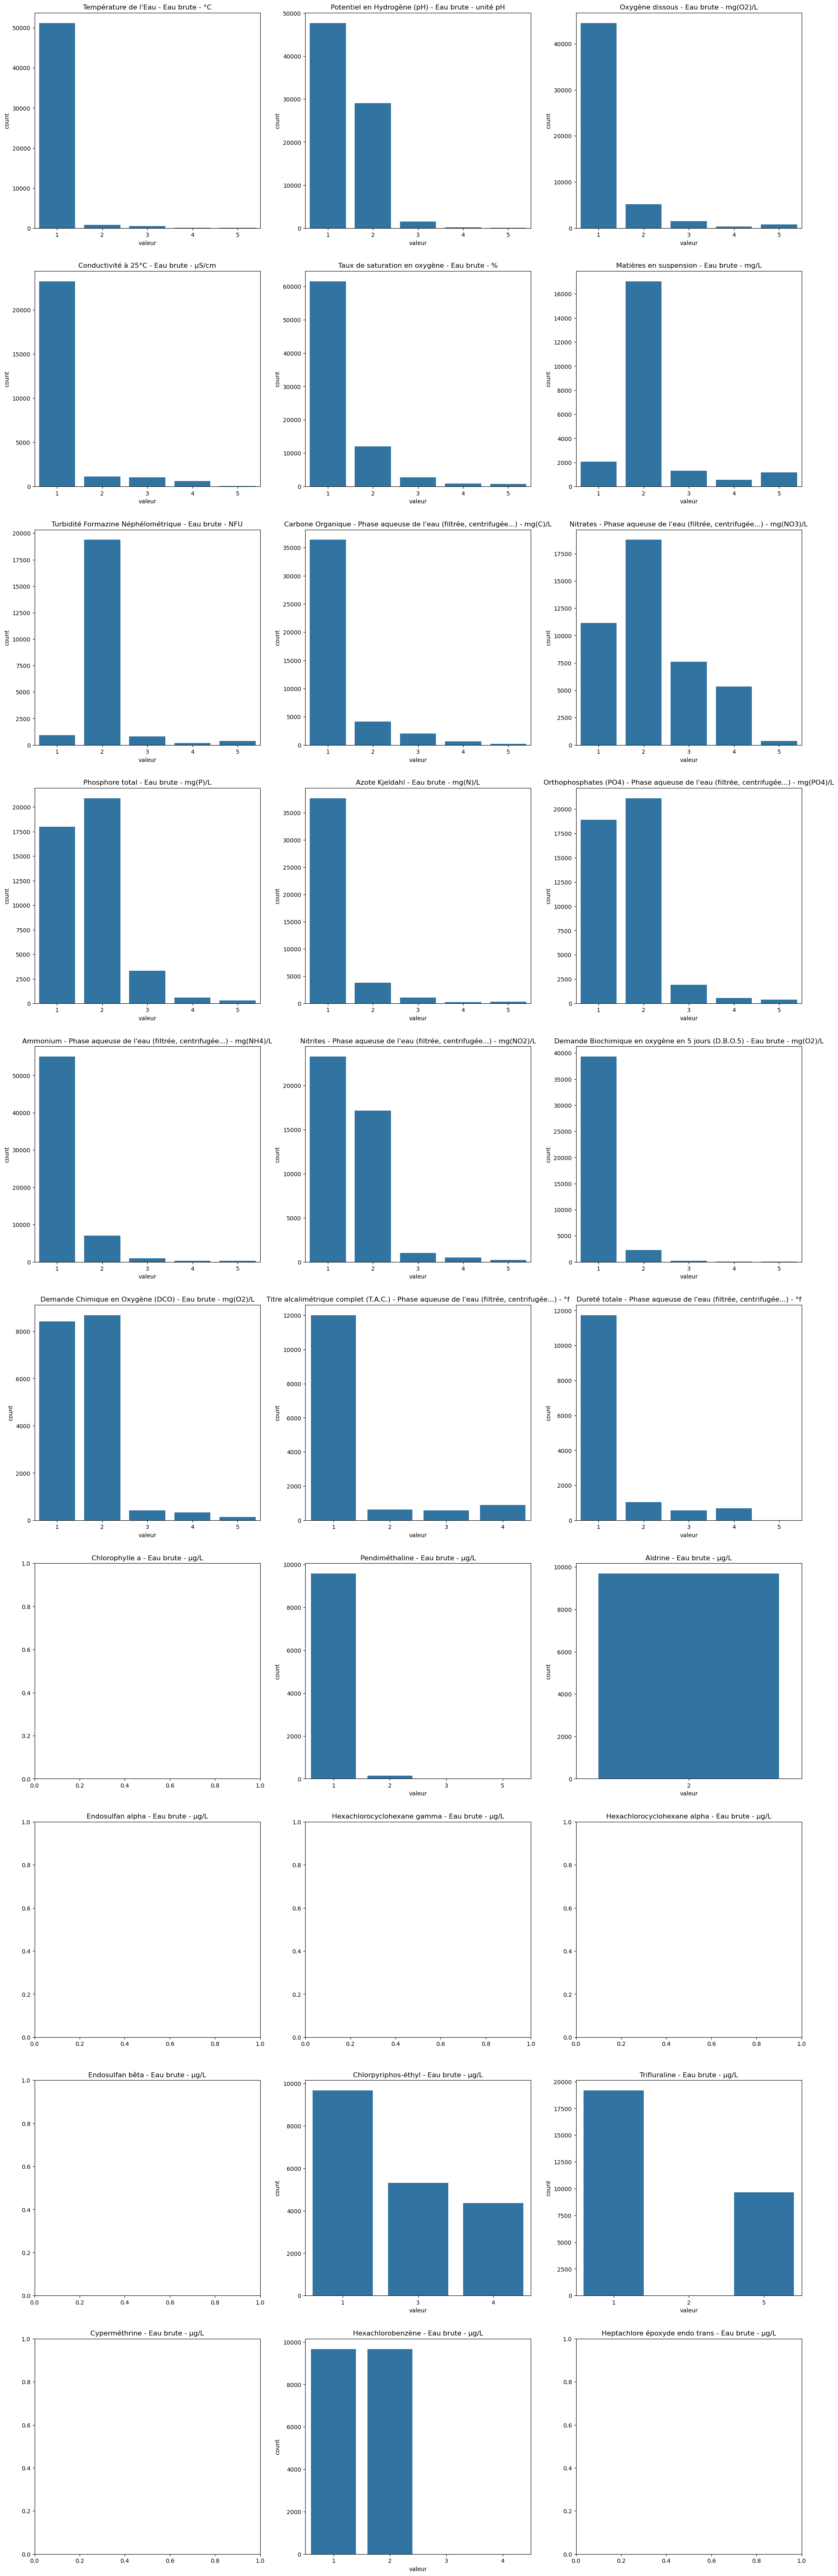

In [17]:
import matplotlib.pyplot as plt
ncols = 3
nrows = len(frequent_parameters)//ncols + ((len(frequent_parameters)%ncols)!=0) 

fig,axs = plt.subplots(nrows,ncols,figsize = (ncols*8,nrows*8))
r,c=0,0
for param in frequent_parameters.index:
    
    df_fp = analyse_merged[analyse_merged['param_frac_unit'] == param]
    sns.countplot(
        data = df_fp,
        x = "valeur",
        ax = axs[c][r]
        ).set(title=param)
    r=(r+1)%ncols
    c += (r==0)


### Complétion des différents paramètres physico-chimiques sur les différentes stations

Obtenir la liste optimale de paramètres pour le plus grand nombre de stations est complexe, on va chercher une approximation satisfaisante

In [18]:
parameter_frequency = analyse_df_slim['param_frac_unit'] \
                        .groupby(analyse_df_slim['param_frac_unit']) \
                        .count() \
                        .sort_values(ascending=False)
parameter_frequency.head(50)

param_frac_unit
Température de l'Eau - Eau brute - °C                                                            26468
Potentiel en Hydrogène (pH) - Eau brute - unité pH                                               26359
Oxygène dissous - Eau brute - mg(O2)/L                                                           26298
Conductivité à 25°C - Eau brute - µS/cm                                                          26216
Taux de saturation en oxygène - Eau brute - %                                                    26141
Matières en suspension - Eau brute - mg/L                                                        22262
Turbidité Formazine Néphélométrique - Eau brute - NFU                                            21923
Carbone Organique - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(C)/L                   21821
Nitrates - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NO3)/L                          21734
Phosphore total - Eau brute - mg(P)/L                    

In [19]:
prel_count = analyse_df_slim['CdPrelevement'].value_counts()
prel_count

CdPrelevement
20220718101831-PC-520929    1688
20220729111652-PC-523527    1677
20220329143828-PC-510382    1672
20220511215956-PC-515850    1672
20220210142512-PC-507756    1666
                            ... 
20221003161851-PC-528015       1
20221003161851-PC-528016       1
801751                         1
801759                         1
801769                         1
Name: count, Length: 27733, dtype: int64

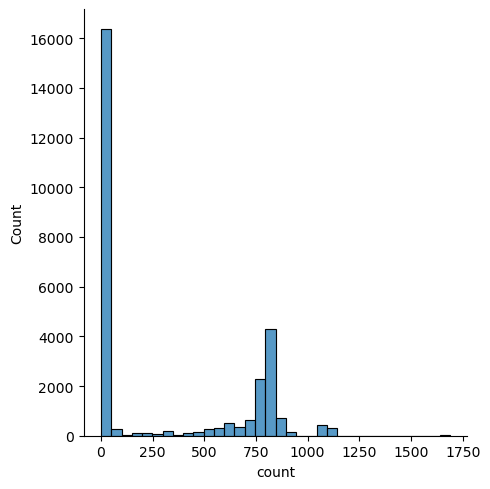

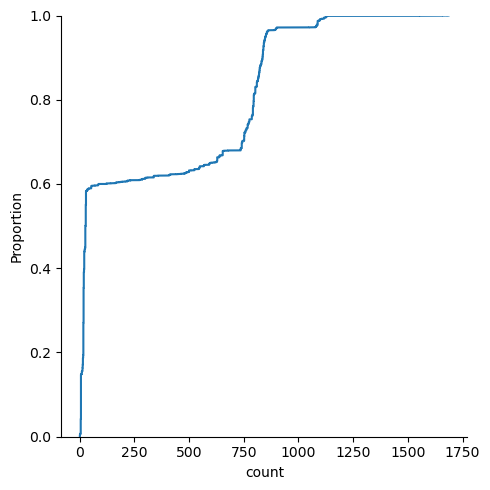

In [20]:
sns.displot(prel_count)
sns.displot(prel_count,kind='ecdf')


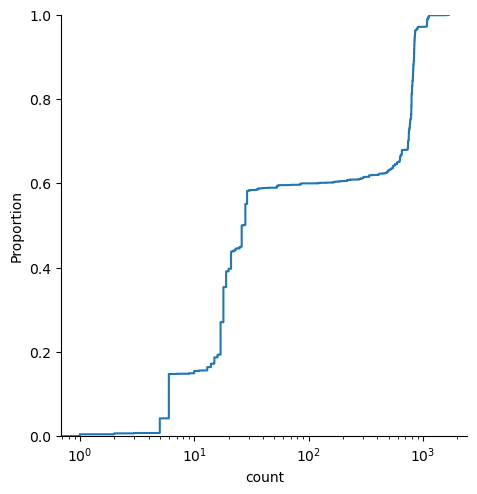

In [21]:
import matplotlib.pyplot as plt
sns.displot(prel_count,kind='ecdf')
plt.xscale('log')

In [22]:
for i in range(10,20):
    print(i,':',prel_count[prel_count>i].shape)

10 : (23439,)
11 : (23415,)
12 : (23408,)
13 : (23190,)
14 : (22967,)
15 : (22549,)
16 : (22370,)
17 : (20229,)
18 : (17922,)
19 : (16887,)


In [23]:
analyse_df_slim['CdStationMesureEauxSurface'].unique()

['01002237', '01002269', '01000457', '01002270', '01002288', ..., '06147660', '06300250', '06700070', '06211700', '06168100']
Length: 3593
Categories (3593, str): ['01000455', '01000457', '01002236', '01002237', ..., 'Y5525003', 'Y6705023', 'Y8415003', 'Y9205023']

In [24]:
df_freq = analyse_df_slim[analyse_df_slim['param_frac_unit'].isin(parameter_frequency.head(15).index)]

df_pivot = pd.pivot_table(data=df_freq,
               values='RsAna',
               index = ['CdStationMesureEauxSurface', 
                        'CdPrelevement',
                        'DatePrel'],
               columns = 'param_frac_unit') \
    .dropna() \
    .reset_index()
df_pivot

param_frac_unit,CdStationMesureEauxSurface,CdPrelevement,DatePrel,"Ammonium - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NH4)/L",Azote Kjeldahl - Eau brute - mg(N)/L,"Carbone Organique - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(C)/L",Conductivité à 25°C - Eau brute - µS/cm,Demande Biochimique en oxygène en 5 jours (D.B.O.5) - Eau brute - mg(O2)/L,Matières en suspension - Eau brute - mg/L,"Nitrates - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NO3)/L","Nitrites - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NO2)/L","Orthophosphates (PO4) - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(PO4)/L",Oxygène dissous - Eau brute - mg(O2)/L,Phosphore total - Eau brute - mg(P)/L,Potentiel en Hydrogène (pH) - Eau brute - unité pH,Taux de saturation en oxygène - Eau brute - %,Température de l'Eau - Eau brute - °C,Turbidité Formazine Néphélométrique - Eau brute - NFU
0,01000455,01000455202208170937222223,2022-08-17,0.02,0.50,0.73,584.0,1.5,3.5,22.0,0.05,0.13,9.90,0.045,7.90,95.0,13.2000,4.32
1,01000457,01000457202208171054222223,2022-08-17,0.05,0.50,1.30,561.0,1.8,3.7,21.0,0.20,0.21,9.40,0.076,8.10,96.0,16.5000,3.00
2,01002236,01002236202208171120222223,2022-08-17,0.02,0.50,1.30,562.0,1.2,2.1,21.0,0.10,0.20,11.10,0.068,8.20,114.0,16.7000,1.50
3,01002237,01002237202201241010222223,2022-01-24,0.05,0.50,0.83,613.0,0.9,13.0,22.0,0.05,0.16,12.20,0.076,8.00,99.0,7.3000,6.70
4,01002237,01002237202202211129222223,2022-02-21,0.05,0.50,2.30,588.0,0.6,21.0,18.0,0.05,0.81,12.00,0.280,8.10,100.0,7.3000,21.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19344,N120510,20220309092238-PC-735376,2022-04-12,0.16,1.20,8.00,230.0,1.3,3.7,6.8,0.08,0.11,10.57,0.068,7.85,104.6,14.3000,1.60
19345,N30-410,20220309092302-PC-735379,2022-04-06,0.19,2.90,3.80,205.0,1.0,5.6,20.0,0.11,0.07,10.65,0.028,7.98,98.7,11.4000,3.70
19346,N303510,20220309092254-PC-735378,2022-04-06,0.02,0.50,3.30,220.0,1.9,3.5,22.0,0.08,0.05,10.95,0.034,8.01,101.3,11.0600,1.20
19347,N330510,20220309092310-PC-735380,2022-04-04,0.14,0.92,7.50,238.0,1.5,6.1,12.0,0.11,0.08,10.42,0.072,7.33,98.0,12.9344,1.77


In [25]:
print('CdPrelevement',df_pivot['CdPrelevement'].unique().shape)
print('CdStationMesureEauxSurface',df_pivot['CdStationMesureEauxSurface'].unique().shape)

CdPrelevement (19349,)
CdStationMesureEauxSurface (2893,)


In [26]:
print('CdPrelevement',             analyse_df_slim['CdPrelevement'].unique().shape)
print('CdStationMesureEauxSurface',analyse_df_slim['CdStationMesureEauxSurface'].unique().shape)

for i in range(5,20):
    df_freq = analyse_df_slim[analyse_df_slim['param_frac_unit'].isin(parameter_frequency.head(i).index)]

    df_pivot = pd.pivot_table(data=df_freq,
                   values='RsAna',
                   index = ['CdStationMesureEauxSurface', 
                            'CdPrelevement',
                            'DatePrel'],
                   columns = 'param_frac_unit') \
        .dropna() \
        .reset_index()
    df_pivot
    print(i)
    print('\t','CdPrelevement',df_pivot['CdPrelevement'].unique().shape)
    print('\t','CdStationMesureEauxSurface',df_pivot['CdStationMesureEauxSurface'].unique().shape)

CdPrelevement (27733,)
CdStationMesureEauxSurface (3593,)
5
	 CdPrelevement (25720,)
	 CdStationMesureEauxSurface (3494,)
6
	 CdPrelevement (21375,)
	 CdStationMesureEauxSurface (3374,)
7
	 CdPrelevement (20794,)
	 CdStationMesureEauxSurface (3238,)
8
	 CdPrelevement (20504,)
	 CdStationMesureEauxSurface (3171,)
9
	 CdPrelevement (20041,)
	 CdStationMesureEauxSurface (3045,)
10
	 CdPrelevement (20041,)
	 CdStationMesureEauxSurface (3045,)
11
	 CdPrelevement (20015,)
	 CdStationMesureEauxSurface (3034,)
12
	 CdPrelevement (20015,)
	 CdStationMesureEauxSurface (3034,)
13
	 CdPrelevement (19886,)
	 CdStationMesureEauxSurface (2989,)
14
	 CdPrelevement (19535,)
	 CdStationMesureEauxSurface (2919,)
15
	 CdPrelevement (19349,)
	 CdStationMesureEauxSurface (2893,)
16
	 CdPrelevement (17167,)
	 CdStationMesureEauxSurface (2191,)
17
	 CdPrelevement (13819,)
	 CdStationMesureEauxSurface (2122,)
18
	 CdPrelevement (13612,)
	 CdStationMesureEauxSurface (2074,)
19
	 CdPrelevement (7532,)
	 CdStatio

In [27]:
#on choisit les 15 paramètres les plus fréquents
df_freq = analyse_df_slim[analyse_df_slim['param_frac_unit'].isin(parameter_frequency.head(15).index)]

df_pivot = pd.pivot_table(data=df_freq,
               values='RsAna',
               index = ['CdStationMesureEauxSurface', 
                        'CdPrelevement',
                        'DatePrel'],
               columns = 'param_frac_unit') \
    .dropna() \
    .reset_index()
df_pivot

param_frac_unit,CdStationMesureEauxSurface,CdPrelevement,DatePrel,"Ammonium - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NH4)/L",Azote Kjeldahl - Eau brute - mg(N)/L,"Carbone Organique - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(C)/L",Conductivité à 25°C - Eau brute - µS/cm,Demande Biochimique en oxygène en 5 jours (D.B.O.5) - Eau brute - mg(O2)/L,Matières en suspension - Eau brute - mg/L,"Nitrates - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NO3)/L","Nitrites - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NO2)/L","Orthophosphates (PO4) - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(PO4)/L",Oxygène dissous - Eau brute - mg(O2)/L,Phosphore total - Eau brute - mg(P)/L,Potentiel en Hydrogène (pH) - Eau brute - unité pH,Taux de saturation en oxygène - Eau brute - %,Température de l'Eau - Eau brute - °C,Turbidité Formazine Néphélométrique - Eau brute - NFU
0,01000455,01000455202208170937222223,2022-08-17,0.02,0.50,0.73,584.0,1.5,3.5,22.0,0.05,0.13,9.90,0.045,7.90,95.0,13.2000,4.32
1,01000457,01000457202208171054222223,2022-08-17,0.05,0.50,1.30,561.0,1.8,3.7,21.0,0.20,0.21,9.40,0.076,8.10,96.0,16.5000,3.00
2,01002236,01002236202208171120222223,2022-08-17,0.02,0.50,1.30,562.0,1.2,2.1,21.0,0.10,0.20,11.10,0.068,8.20,114.0,16.7000,1.50
3,01002237,01002237202201241010222223,2022-01-24,0.05,0.50,0.83,613.0,0.9,13.0,22.0,0.05,0.16,12.20,0.076,8.00,99.0,7.3000,6.70
4,01002237,01002237202202211129222223,2022-02-21,0.05,0.50,2.30,588.0,0.6,21.0,18.0,0.05,0.81,12.00,0.280,8.10,100.0,7.3000,21.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19344,N120510,20220309092238-PC-735376,2022-04-12,0.16,1.20,8.00,230.0,1.3,3.7,6.8,0.08,0.11,10.57,0.068,7.85,104.6,14.3000,1.60
19345,N30-410,20220309092302-PC-735379,2022-04-06,0.19,2.90,3.80,205.0,1.0,5.6,20.0,0.11,0.07,10.65,0.028,7.98,98.7,11.4000,3.70
19346,N303510,20220309092254-PC-735378,2022-04-06,0.02,0.50,3.30,220.0,1.9,3.5,22.0,0.08,0.05,10.95,0.034,8.01,101.3,11.0600,1.20
19347,N330510,20220309092310-PC-735380,2022-04-04,0.14,0.92,7.50,238.0,1.5,6.1,12.0,0.11,0.08,10.42,0.072,7.33,98.0,12.9344,1.77


### correlation

<Axes: xlabel='param_frac_unit', ylabel='param_frac_unit'>

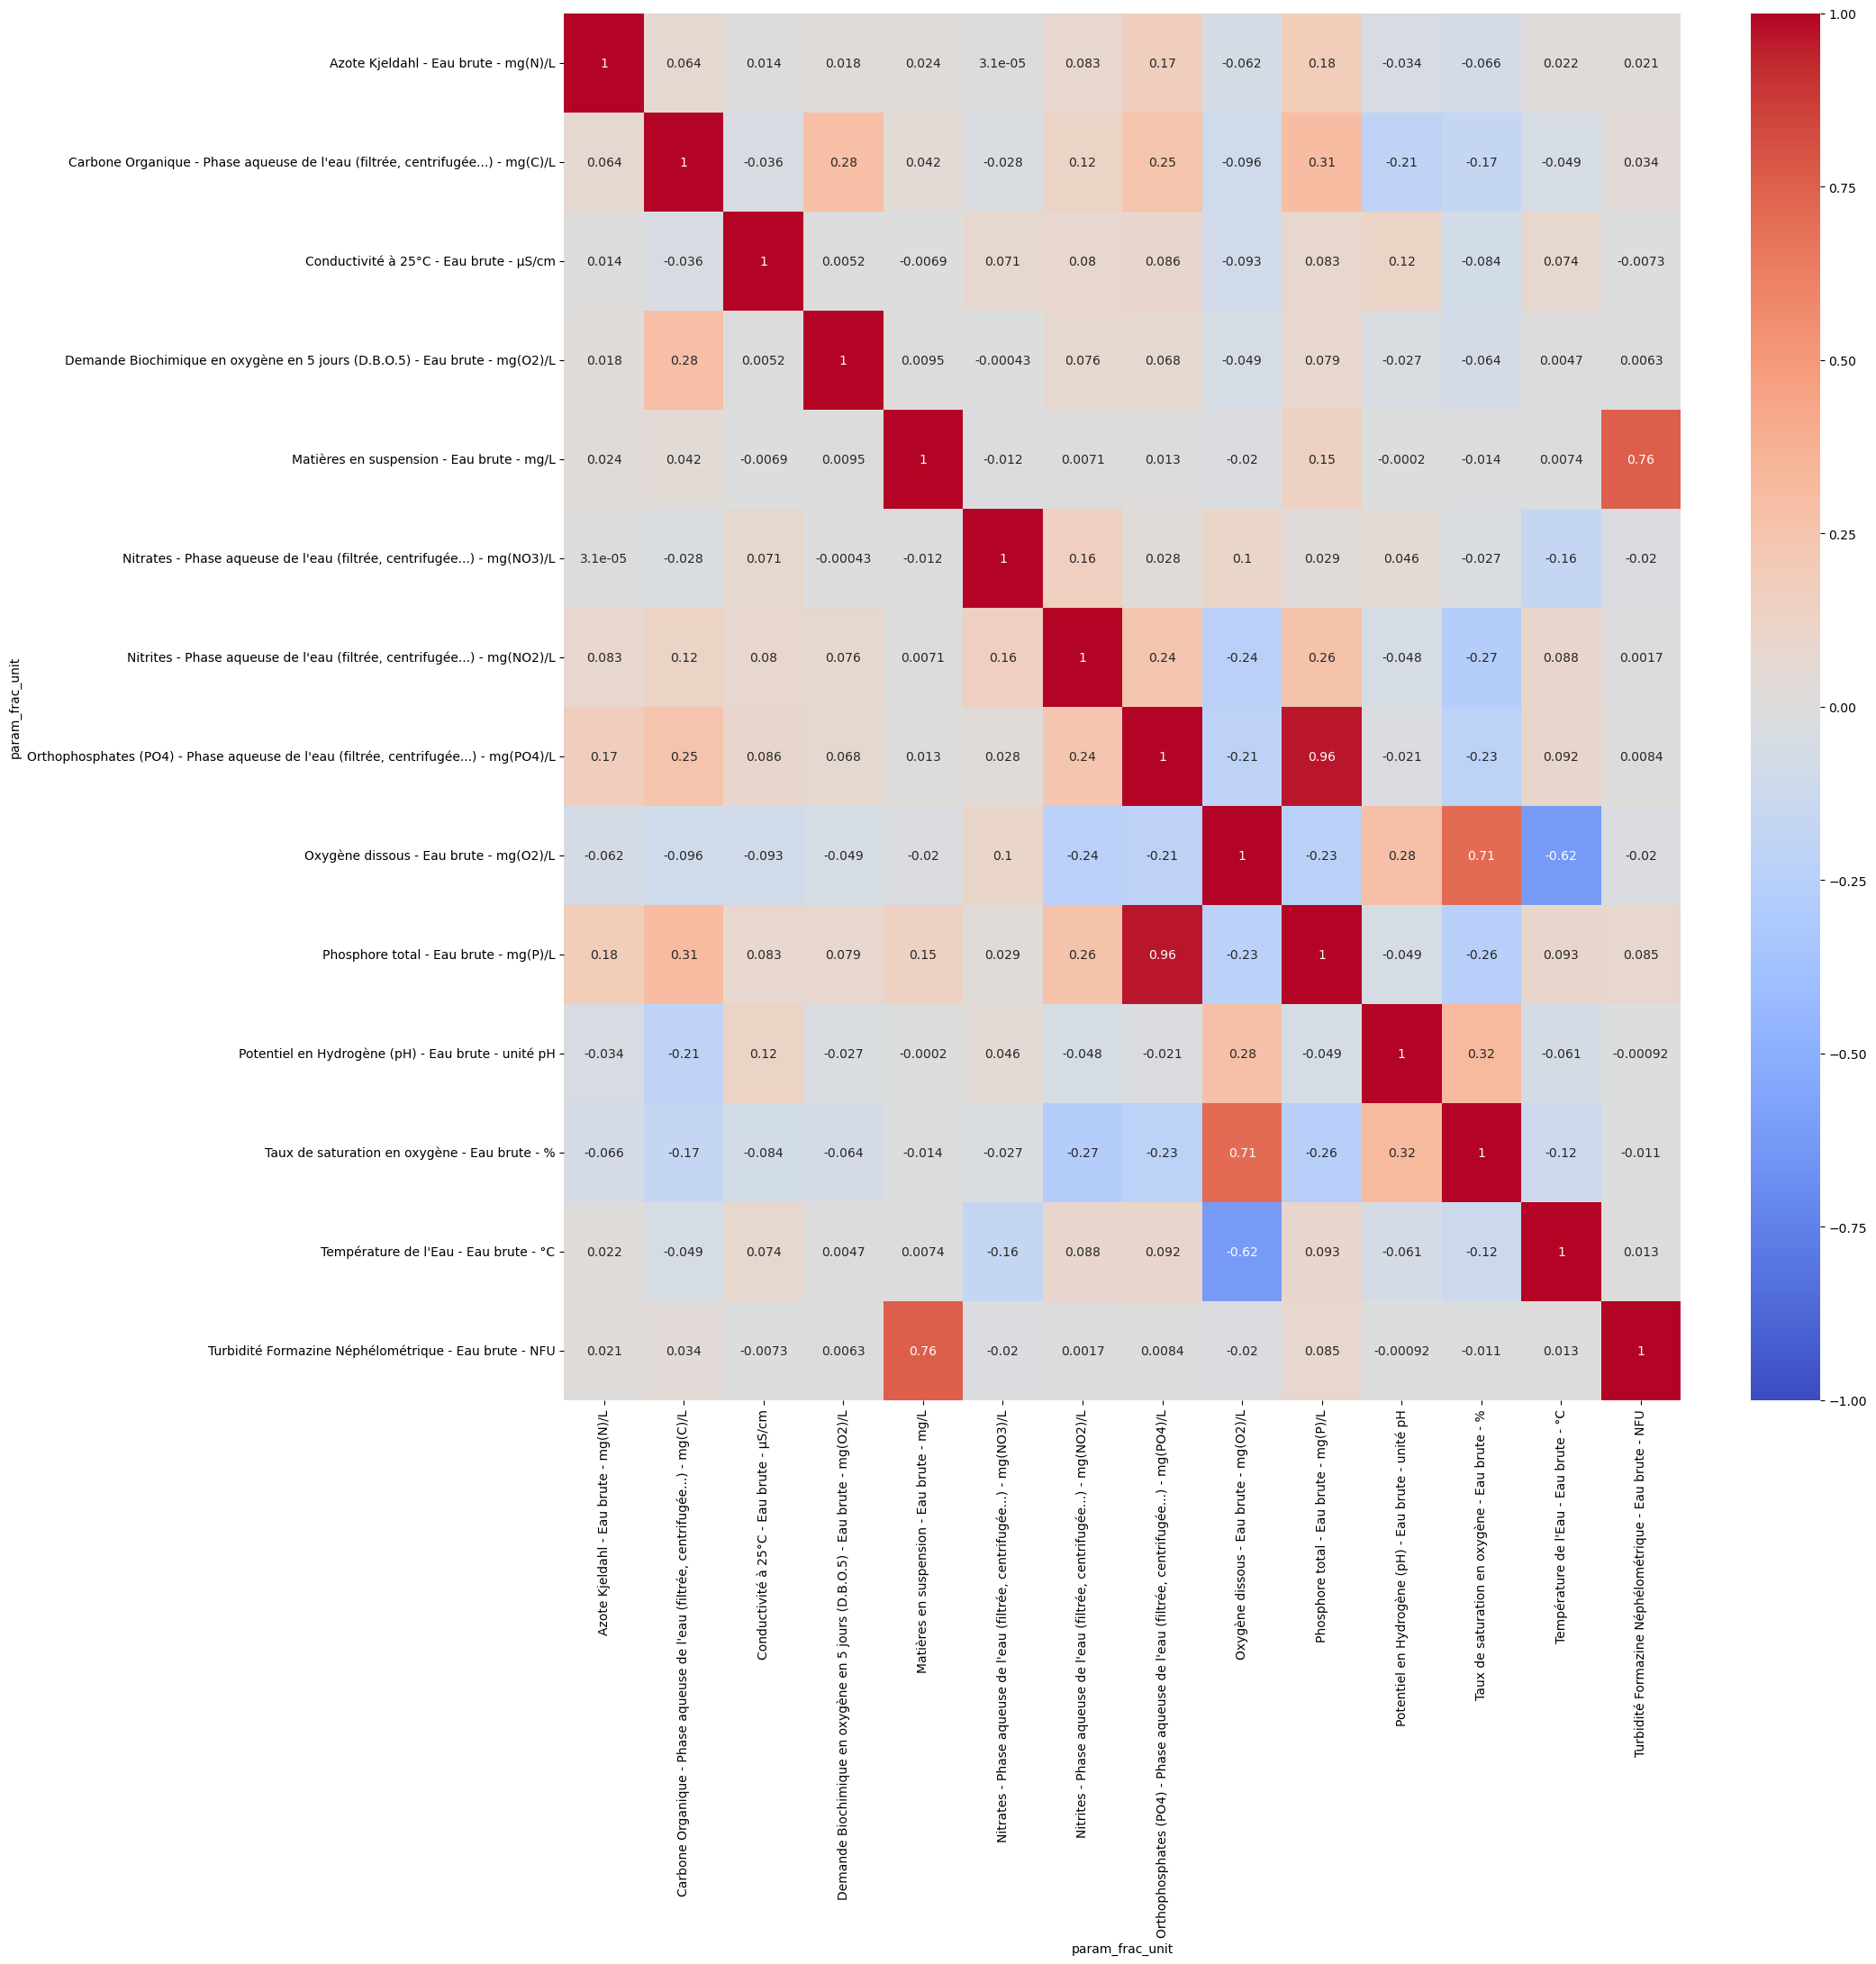

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(20,20))
sns.heatmap(df_pivot.iloc[:,4:].corr(),
            vmin=-1,
            vmax=1,
            annot=True,
            cmap='coolwarm')

In [29]:
param_alteration = analyse_merged[['param_frac_unit','alteration_nom']].drop_duplicates().set_index('param_frac_unit')
param_alteration.index.unique()

CategoricalIndex(['Turbidité Formazine Néphélométrique - Eau brute - NFU',
                  'Température de l'Eau - Eau brute - °C',
                  'Potentiel en Hydrogène (pH) - Eau brute - unité pH',
                  'Conductivité à 25°C - Eau brute - µS/cm',
                  'Oxygène dissous - Eau brute - mg(O2)/L',
                  'Taux de saturation en oxygène - Eau brute - %',
                  'Matières en suspension - Eau brute - mg/L',
                  'Demande Biochimique en oxygène en 5 jours (D.B.O.5) - Eau brute - mg(O2)/L',
                  'Demande Chimique en Oxygène (DCO) - Eau brute - mg(O2)/L',
                  'Azote Kjeldahl - Eau brute - mg(N)/L',
                  ...
                  'Xylène-méta - Sédiments bruts - µg/(kg MS)',
                  'Xylène-para - Sédiments bruts - µg/(kg MS)',
                  '2,4-D-ester - Eau brute - µg/L',
                  'PCB 101 - Matière sèche de particules < 2 mm - µg/kg',
                  'PCB 118 - Matièr

In [103]:
df_corr = df_pivot.iloc[:,4:].corr()
for x in df_corr.index:
    for y in df_corr.columns:
        if 1>abs(df_corr.loc[x,y])>0.5:
            print('correlation:',df_corr.loc[x,y])
            print(x,list(param_alteration.loc[[x],'alteration_nom'].values))
            print(y,list(param_alteration.loc[[y],'alteration_nom'].values))
            print()

correlation: 0.7570169945796988
Matières en suspension - Eau brute - mg/L ['PAES']
Turbidité Formazine Néphélométrique - Eau brute - NFU ['PAES']

correlation: 0.9609458232123879
Orthophosphates (PO4) - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(PO4)/L ['NUTRI', 'PHOS']
Phosphore total - Eau brute - mg(P)/L ['NUTRI', 'PHOS']

correlation: 0.7106255296407127
Oxygène dissous - Eau brute - mg(O2)/L ['BILO2', 'MOOX']
Taux de saturation en oxygène - Eau brute - % ['BILO2', 'EPRV', 'MOOX']

correlation: -0.6211078311244305
Oxygène dissous - Eau brute - mg(O2)/L ['BILO2', 'MOOX']
Température de l'Eau - Eau brute - °C ['TEMP']

correlation: 0.9609458232123879
Phosphore total - Eau brute - mg(P)/L ['NUTRI', 'PHOS']
Orthophosphates (PO4) - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(PO4)/L ['NUTRI', 'PHOS']

correlation: 0.7106255296407127
Taux de saturation en oxygène - Eau brute - % ['BILO2', 'EPRV', 'MOOX']
Oxygène dissous - Eau brute - mg(O2)/L ['BILO2', 'MOOX']

correla

# TP2 - Aggrégation et clustering

## Aggrégation par moyenne

on part ici du dataframe `df_freq` la moyenne va se faire sur les données brutes.

In [32]:
df_freq.columns

Index(['CdStationMesureEauxSurface', 'LbStationMesureEauxSurface', 'CdSupport',
       'LbSupport', 'CdFractionAnalysee', 'LbFractionAnalysee',
       'CdPrelevement', 'DatePrel', 'CdParametre', 'LbLongParamètre', 'RsAna',
       'CdUniteMesure', 'SymUniteMesure', 'CdRqAna', 'MnemoRqAna', 'LdAna',
       'LqAna', 'param_frac_unit'],
      dtype='str')

In [53]:
df_agg_mean = df_freq[['CdStationMesureEauxSurface', 'param_frac_unit','RsAna']]\
    .groupby(by=['CdStationMesureEauxSurface', 'param_frac_unit'])\
    .mean()\
    .reset_index(level=1)\
    .pivot(columns='param_frac_unit')
df_agg_mean

RsAna  \
param_frac_unit            Ammonium - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NH4)/L   
CdStationMesureEauxSurface                                                                           
01000455                                                             0.020000                        
01000457                                                             0.050000                        
01002236                                                             0.020000                        
01002237                                                             0.040000                        
01002269                                                             0.046250                        
...                                                                       ...                        
Y4305143                                                             0.175000                        
Y5525003                                                             0.012500                        
Y6705023                                                             0.010000                        
Y8415003                                                             0.032500                        
Y9205023                                                             0.013333                        

                                                                 \
param_frac_unit            Azote Kjeldahl - Eau brute - mg(N)/L   
CdStationMesureEauxSurface                                        
01000455                                                 0.5000   
01000457                                                 0.5000   
01002236                                                 0.5000   
01002237                                                 0.5000   
01002269                                                 0.5000   
...                                                         ...   
Y4305143                                                 1.5750   
Y5525003                                                 0.5075   
Y6705023                                                 0.5000   
Y8415003                                                 0.5000   
Y9205023                                                 0.5000   

                                                                                                           \
param_frac_unit            Carbone Organique - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(C)/L   
CdStationMesureEauxSurface                                                                                  
01000455                                                             0.730000                               
01000457                                                             1.300000                               
01002236                                                             1.300000                               
01002237                                                             1.346250                               
01002269                                                             1.442500                               
...                                                                       ...                               
Y4305143                                                             4.162500                               
Y5525003                                                             1.700000                               
Y6705023                                                             0.297500                               
Y8415003                                                             1.625000                               
Y9205023                                                             1.633333                               

                                                                    \
param_frac_unit            Conductivité à 25°C - Eau brute - µS/cm   
CdStationMesureEauxSurface                                

## Aggrégation par percentile 95

In [47]:
df_freq_seq = df_freq.merge(seq_eau,left_on="CdParametre",right_on="parametre_id")

cond_inf = df_freq_seq.borne_inf.isna() | (df_freq_seq.borne_inf_incluse & (df_freq_seq.borne_inf <=  df_freq_seq.RsAna)) | (df_freq_seq.borne_inf < df_freq_seq.RsAna)
cond_sup = df_freq_seq.borne_sup.isna() | (df_freq_seq.borne_sup_incluse & (df_freq_seq.borne_sup >=  df_freq_seq.RsAna)) | (df_freq_seq.borne_sup > df_freq_seq.RsAna)
df_freq_seq = df_freq_seq[cond_inf & cond_sup]

In [48]:
df_freq_seq

,CdStationMesureEauxSurface,LbStationMesureEauxSurface,CdSupport,LbSupport,CdFractionAnalysee,LbFractionAnalysee,CdPrelevement,DatePrel,CdParametre,LbLongParamètre,...,parametre_nom,alteration_id,alteration_nom,valeur,libelle,borne_inf_incluse,borne_sup_incluse,borne_inf,borne_sup,unite_mesure_code
1,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,1295,Turbidité Formazine Néphélométrique,...,Turbidité Formazine Néphélométrique,13,PAES,2,Vert,True,False,1.0,35.00,233
5,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,1301,Température de l'Eau,...,Température de l'Eau,0,TEMP,1,Bleu,True,False,NaN,24.00,27
10,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,1301,Température de l'Eau,...,Température de l'Eau,8,TEMP,1,Bleu,True,False,NaN,24.00,27
20,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,1302,Potentiel en Hydrogène (pH),...,Potentiel en Hydrogène (pH),1,ACID,2,Vert,True,False,8.2,9.00,264
25,01002237,HEM ET MEULESTROM A TOURNEHEM SUR LA HEM (62) [3],3,Eau,23,Eau brute,01002237202204061010222223,2022-04-06,1302,Potentiel en Hydrogène (pH),...,Potentiel en Hydrogène (pH),6,EPRV,2,Vert,True,False,8.0,8.50,264
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3765033,06133330,DORON DE CHAMPAGNY A CHAMPAGNY-EN-VANOISE 2,3,Eau,23,Eau brute,778243,2022-10-25,1350,Phosphore total,...,Phosphore total,12,PHOS,1,Bleu,True,False,NaN,0.05,162
3765038,06133330,DORON DE CHAMPAGNY A CHAMPAGNY-EN-VANOISE 2,3,Eau,3,"Phase aqueuse de l'eau (filtrée, centrifugée...)",778243,2022-10-25,1433,Orthophosphates (PO4),...,Orthophosphates (PO4),3,NUTRI,1,Bleu,True,False,NaN,0.10,162
3765043,06133330,DORON DE CHAMPAGNY A CHAMPAGNY-EN-VANOISE 2,3,Eau,3,"Phase aqueuse de l'eau (filtrée, centrifugée...)",778243,2022-10-25,1433,Orthophosphates (PO4),...,Orthophosphates (PO4),12,PHOS,1,Bleu,True,False,NaN,0.10,162
3765048,06133330,DORON DE CHAMPAGNY A CHAMPAGNY-EN-VANOISE 2,3,Eau,3,"Phase aqueuse de l'eau (filtrée, centrifugée...)",778243,2022-10-25,1841,Carbone Organique,...,Carbone Organique,2,BILO2,1,Bleu,True,False,NaN,5.00,162


In [52]:
df_agg_p95 = df_freq_seq[['CdStationMesureEauxSurface', 'param_frac_unit','valeur']]\
    .groupby(by=['CdStationMesureEauxSurface', 'param_frac_unit'])\
    .quantile(0.95,interpolation='nearest')\
    .reset_index(level=1)\
    .pivot(columns='param_frac_unit')
df_agg_p95

valeur  \
param_frac_unit            Ammonium - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NH4)/L   
CdStationMesureEauxSurface                                                                           
01000455                                                                  1.0                        
01000457                                                                  1.0                        
01002236                                                                  1.0                        
01002237                                                                  1.0                        
01002269                                                                  2.0                        
...                                                                       ...                        
Y4305143                                                                  3.0                        
Y5525003                                                                  1.0                        
Y6705023                                                                  1.0                        
Y8415003                                                                  1.0                        
Y9205023                                                                  1.0                        

                                                                 \
param_frac_unit            Azote Kjeldahl - Eau brute - mg(N)/L   
CdStationMesureEauxSurface                                        
01000455                                                    1.0   
01000457                                                    1.0   
01002236                                                    1.0   
01002237                                                    1.0   
01002269                                                    1.0   
...                                                         ...   
Y4305143                                                    3.0   
Y5525003                                                    1.0   
Y6705023                                                    1.0   
Y8415003                                                    1.0   
Y9205023                                                    1.0   

                                                                                                           \
param_frac_unit            Carbone Organique - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(C)/L   
CdStationMesureEauxSurface                                                                                  
01000455                                                                  1.0                               
01000457                                                                  1.0                               
01002236                                                                  1.0                               
01002237                                                                  1.0                               
01002269                                                                  1.0                               
...                                                                       ...                               
Y4305143                                                                  2.0                               
Y5525003                                                                  1.0                               
Y6705023                                                                  1.0                               
Y8415003                                                                  1.0                               
Y9205023                                                                  1.0                               

                                                                    \
param_frac_unit            Conductivité à 25°C - Eau brute - µS/cm   
CdStationMesureEauxSurface                               

valeur  \
param_frac_unit            Ammonium - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(NH4)/L   
CdStationMesureEauxSurface                                                                           
01000455                                                                 1.00                        
01000457                                                                 1.00                        
01002236                                                                 1.00                        
01002237                                                                 1.00                        
01002269                                                                 1.85                        
...                                                                       ...                        
Y4305143                                                                 2.85                        
Y5525003                                                                 1.00                        
Y6705023                                                                 1.00                        
Y8415003                                                                 1.00                        
Y9205023                                                                 1.00                        

                                                                 \
param_frac_unit            Azote Kjeldahl - Eau brute - mg(N)/L   
CdStationMesureEauxSurface                                        
01000455                                                    1.0   
01000457                                                    1.0   
01002236                                                    1.0   
01002237                                                    1.0   
01002269                                                    1.0   
...                                                         ...   
Y4305143                                                    3.0   
Y5525003                                                    1.0   
Y6705023                                                    1.0   
Y8415003                                                    1.0   
Y9205023                                                    1.0   

                                                                                                           \
param_frac_unit            Carbone Organique - Phase aqueuse de l'eau (filtrée, centrifugée...) - mg(C)/L   
CdStationMesureEauxSurface                                                                                  
01000455                                                                  1.0                               
01000457                                                                  1.0                               
01002236                                                                  1.0                               
01002237                                                                  1.0                               
01002269                                                                  1.0                               
...                                                                       ...                               
Y4305143                                                                  2.0                               
Y5525003                                                                  1.0                               
Y6705023                                                                  1.0                               
Y8415003                                                                  1.0                               
Y9205023                                                                  1.0                               

                                                                    \
param_frac_unit            Conductivité à 25°C - Eau brute - µS/cm   
CdStationMesureEauxSurface                               

## Clustering

In [57]:
len(df_agg_p95)

3572

In [65]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_mean = scaler.fit_transform(df_agg_mean.dropna())


In [64]:
X_p95 = df_agg_p95.dropna()

For n_clusters = 3 The average silhouette_score is : 0.2549847171389351
For n_clusters = 4 The average silhouette_score is : 0.23463057028457893
For n_clusters = 5 The average silhouette_score is : 0.22006865354249708
For n_clusters = 6 The average silhouette_score is : 0.18107313248368725
For n_clusters = 7 The average silhouette_score is : 0.13980592395379113
For n_clusters = 8 The average silhouette_score is : 0.13513247955243993
For n_clusters = 9 The average silhouette_score is : 0.1342498995661128


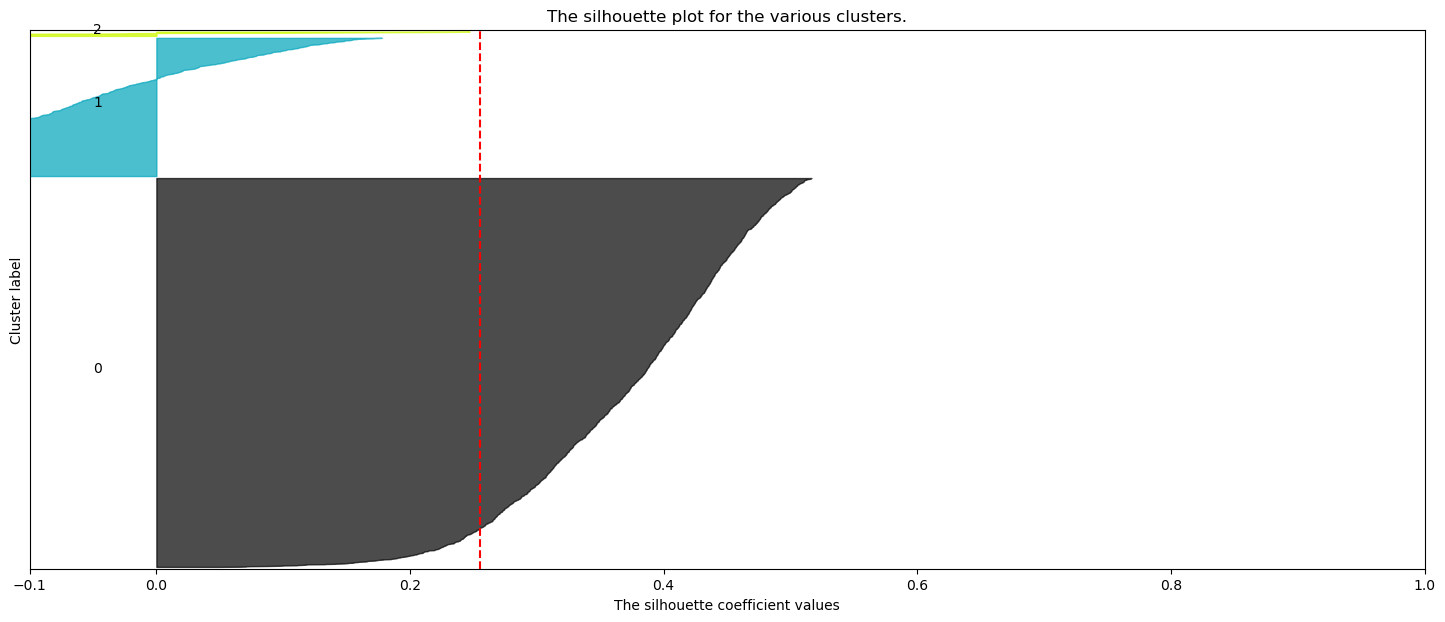

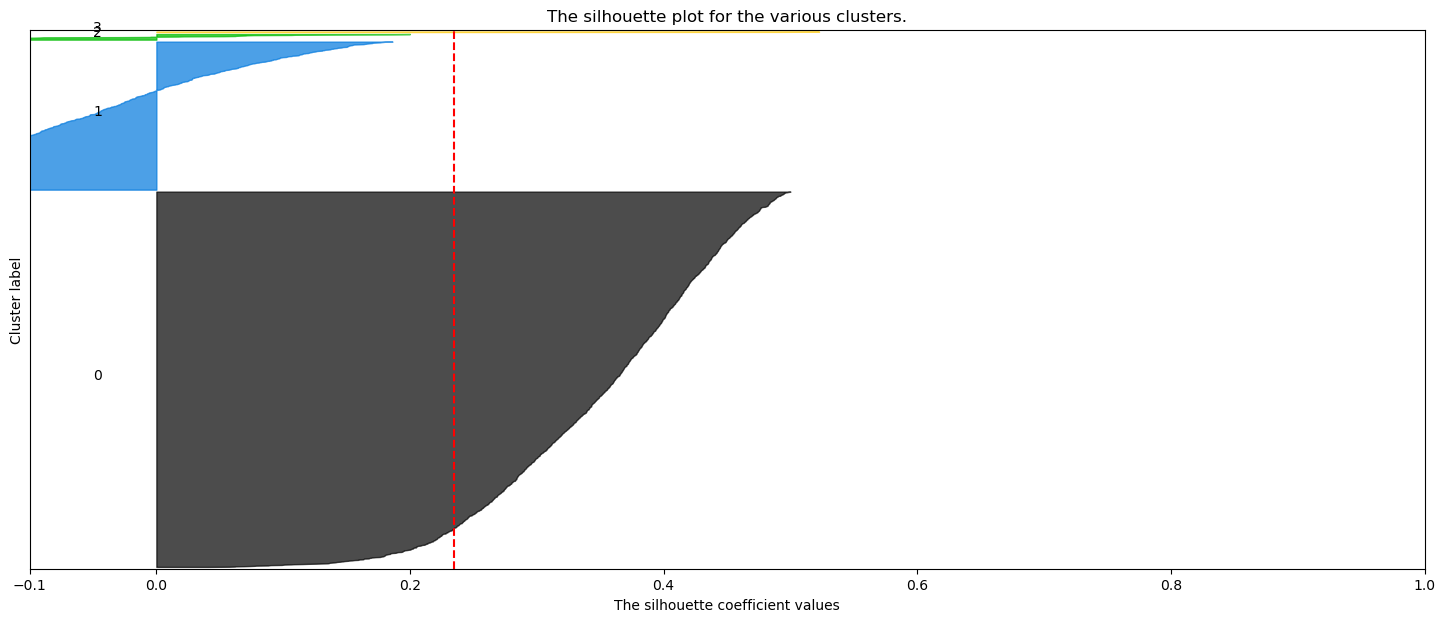

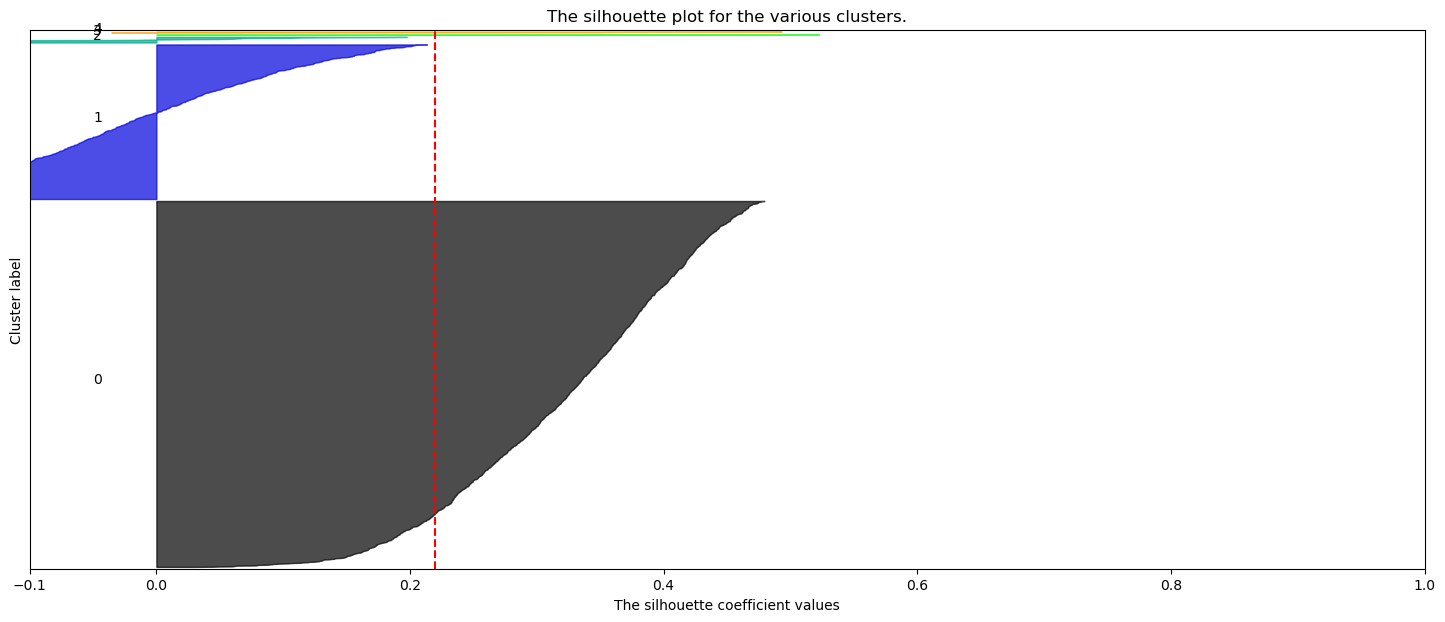

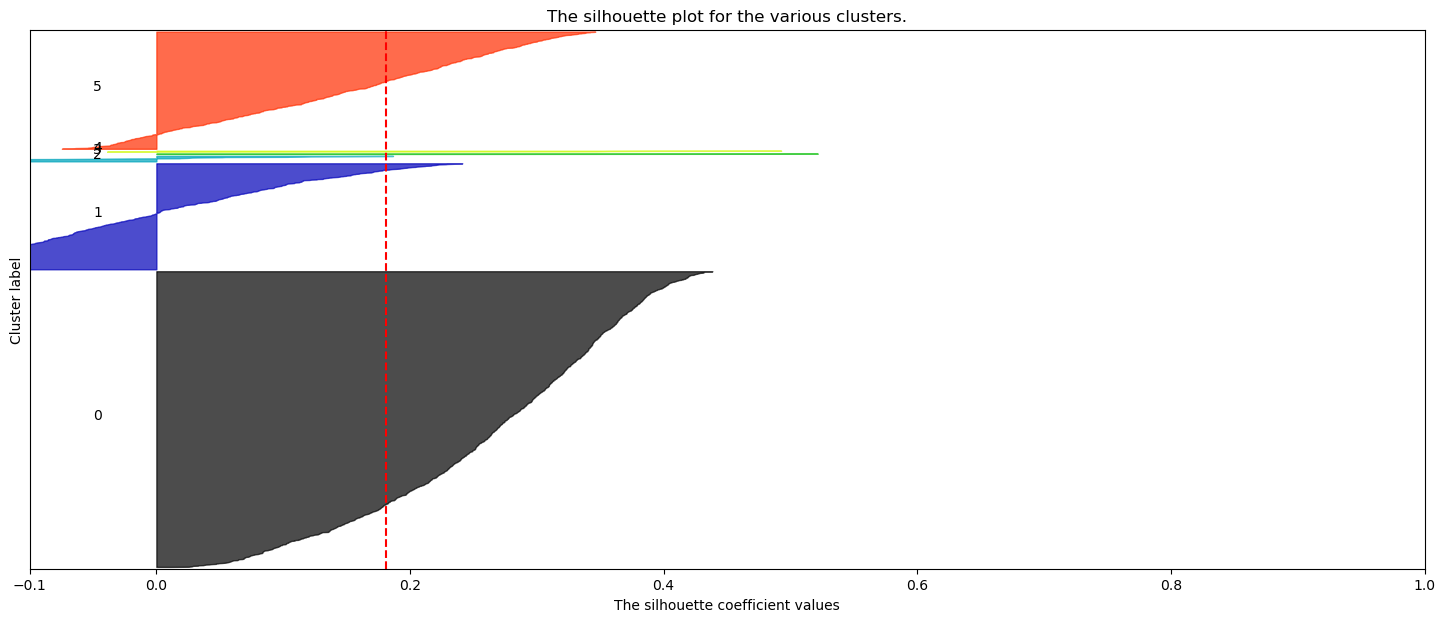

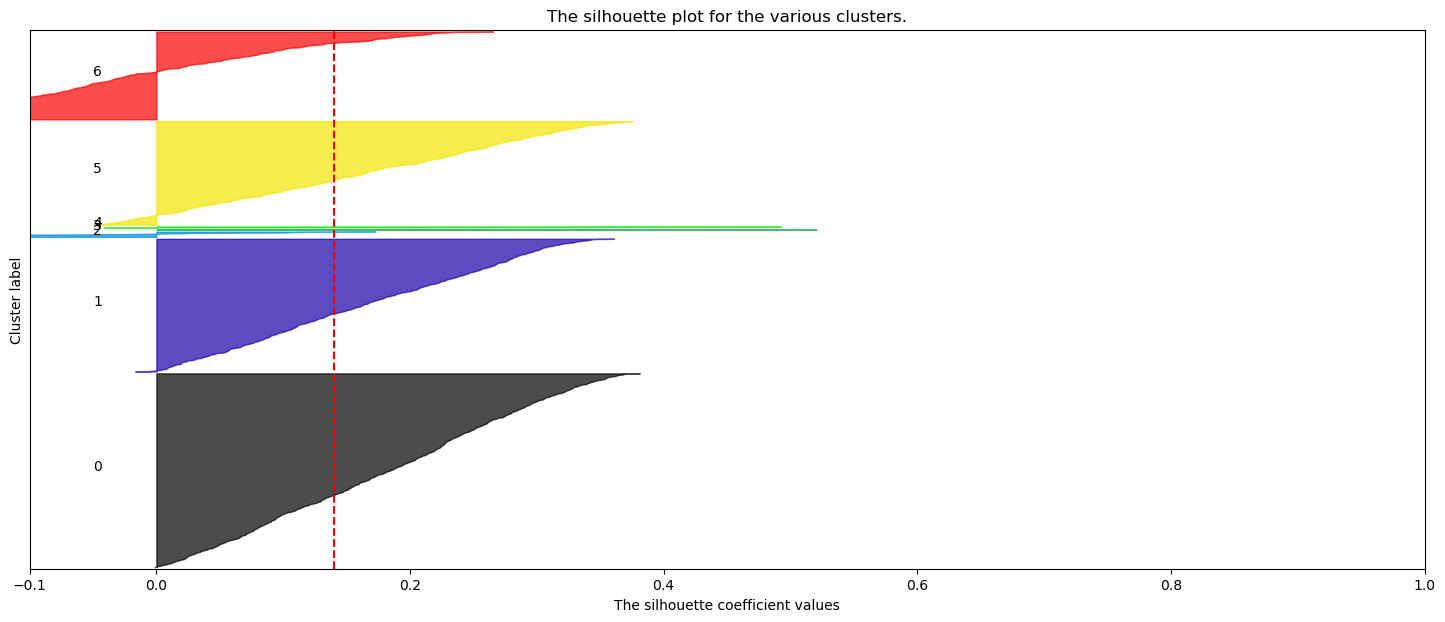

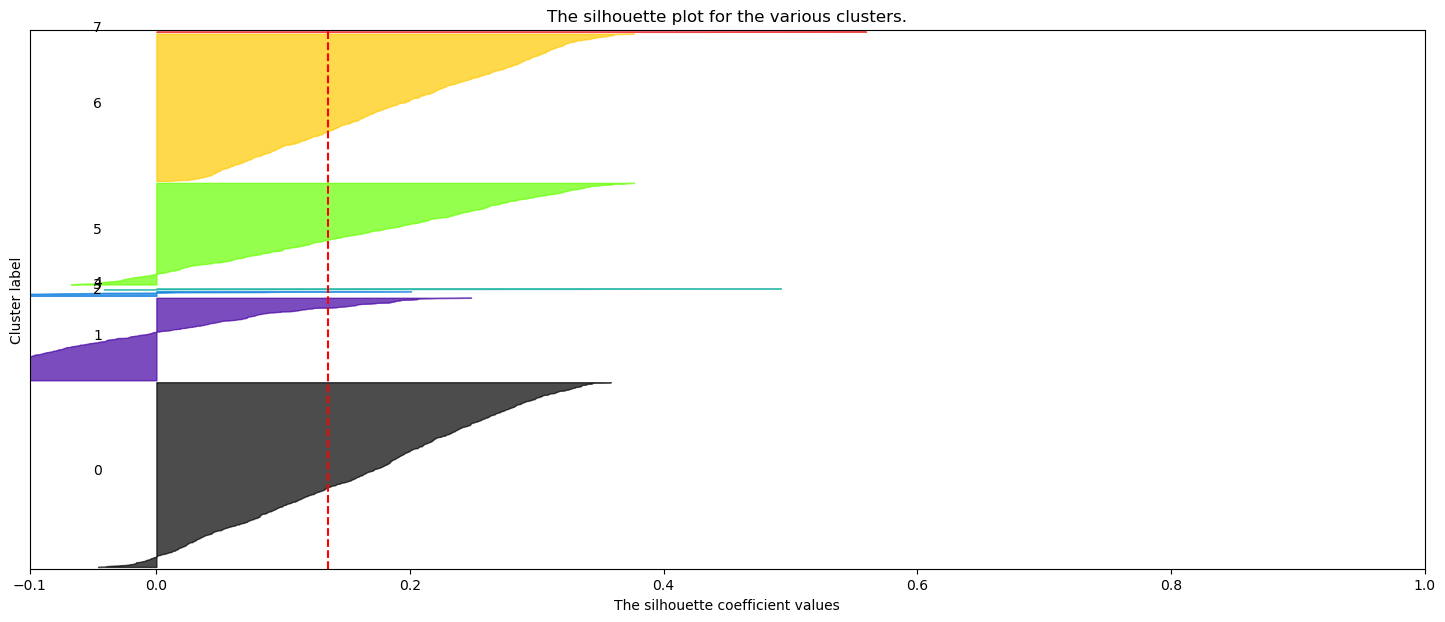

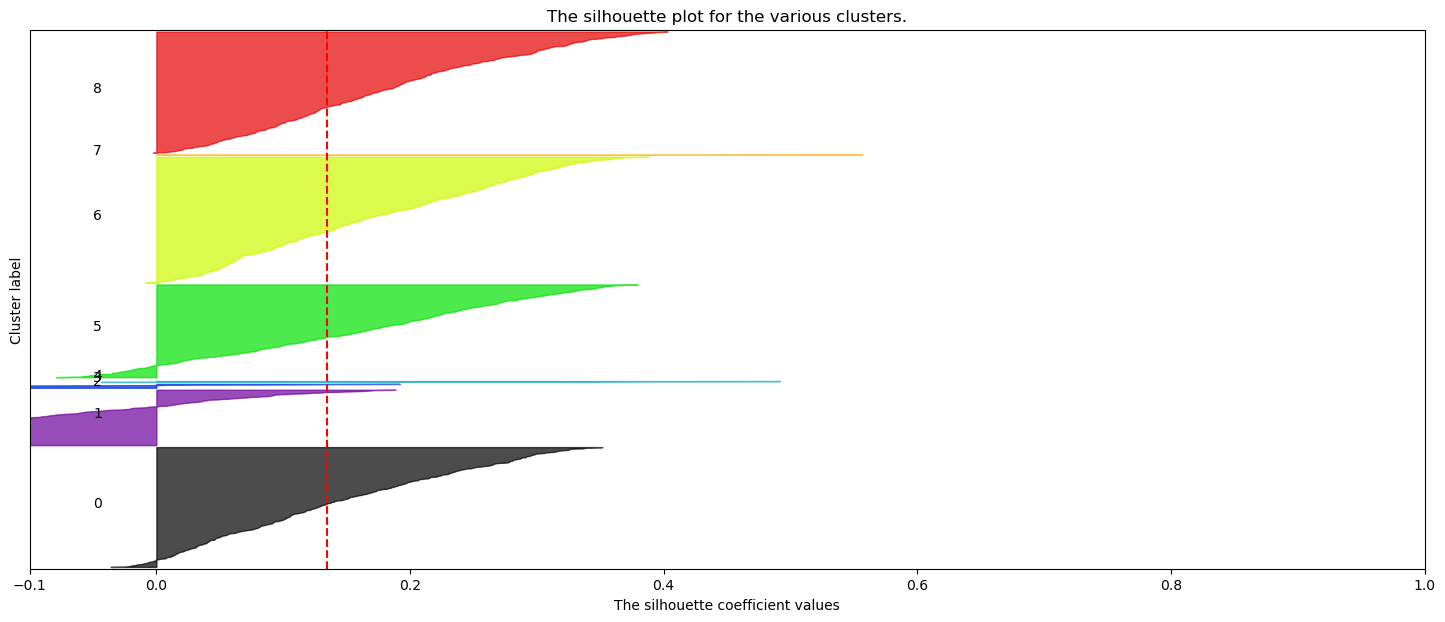

In [90]:
#code d'analyse de silhouette provenant de la documentation de scikitlearn
#https://sklearn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html

# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_samples, silhouette_score

X = X_mean

for n_clusters in range(3,10):
    # Create a subplot with 1 row and 2 columns
    fig, ax1 = plt.subplots()
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    
   

   


plt.show()

# TP3 - Données géographiques

## Chargement stations

In [79]:
import pandas as pd
import geopandas as gpd
import shapely.geometry as geom
import os



df_stations = pd.read_csv("stations.csv.zst",sep=';',escapechar = '\\')
#on ne garde que les stations que l'on étudie
df_stations = df_stations[df_stations['CdStationMesureEauxSurface'].isin(df_freq['CdStationMesureEauxSurface'])]

/tmp/ipykernel_11129/1820050023.py:8: DtypeWarning: Columns (0: CdEuMasseDEau, 1: NomMasseDEau, 2: CdEuSsBassinDCEAdmin, 3: NomSsBassinDCEAdmin, 4: CdBassinDCE, 5: CdEuBassinDCE, 6: NomEuBassinDCE) have mixed types. Specify dtype option on import or set low_memory=False.
  df_stations = pd.read_csv("stations.csv.zst",sep=';',escapechar = '\\')


In [88]:

#crs_lambert = 'PROJCS["RGF_1993_Lambert_93",GEOGCS["GCS_RGF_1993",DATUM["D_RGF_1993",SPHEROID["GRS_1980",6378137.0,298.257222101]],PRIMEM["Greenwich",0.0],UNIT["Degree",0.0174532925199433]],PROJECTION["Lambert_Conformal_Conic"],PARAMETER["False_Easting",700000.0],PARAMETER["False_Northing",6600000.0],PARAMETER["Central_Meridian",3.0],PARAMETER["Standard_Parallel_1",49.0],PARAMETER["Standard_Parallel_2",44.0],PARAMETER["Latitude_Of_Origin",46.5],UNIT["Meter",1.0]]'
x_col = 'CoordXStationMesureEauxSurface'
y_col = 'CoordYStationMesureEauxSurface'

carto = gpd.GeoDataFrame(df_stations,crs="EPSG:2154" ,
                        geometry = gpd.GeoSeries(df_stations.agg(lambda x:geom.Point(x.loc[x_col],x.loc[y_col])  ,axis=1)))

<Axes: >

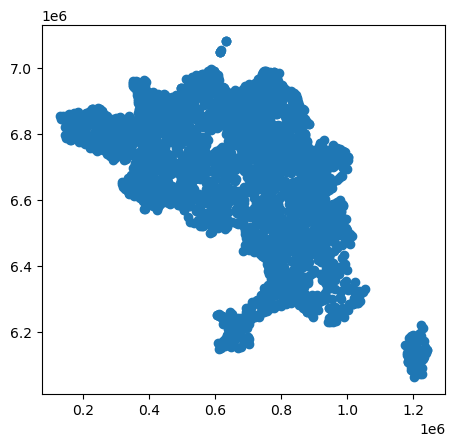

In [89]:
carto.plot()

In [83]:
clc = gpd.read_file("CLC_PNE_RG/CORINE_LAND_COVER_FRANCE_METROPOLITAINE_EPSG2154.gpkg")

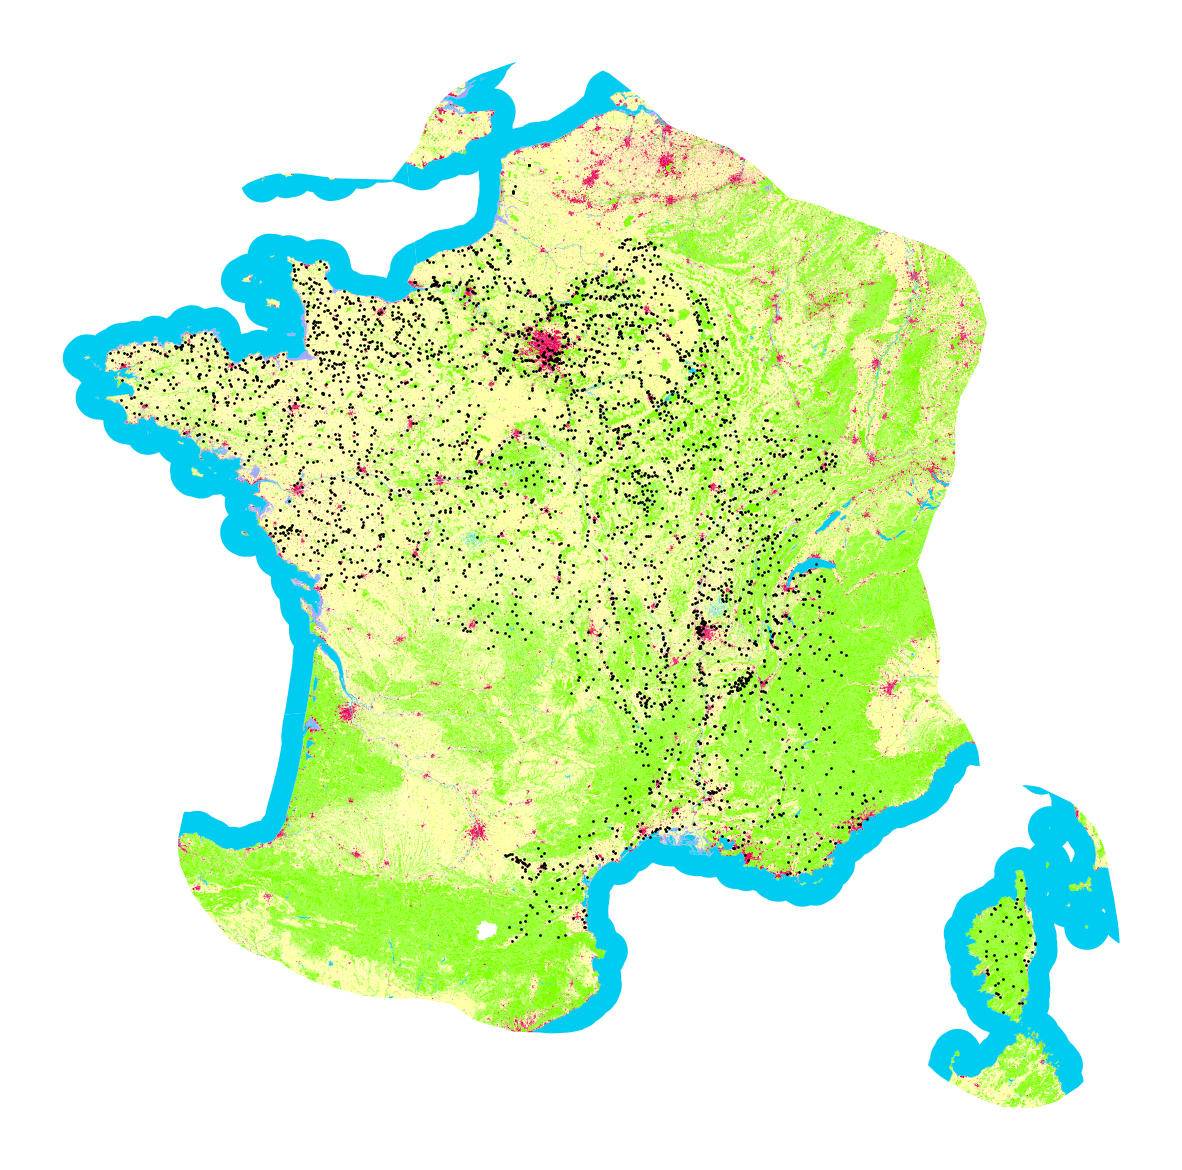

In [84]:
import matplotlib.pyplot as plt
import numpy as np

legend = {
    "1" : "#E6004D",
    "2" : "#FFFFA8",
    "3" : "#80FF00",
    "4" : "#A6A6FF",
    "5" : "#00CCF2"}
fig, ax = plt.subplots(figsize=(15,15)) 
for i in legend:
    clc[clc.code_18.str.startswith(i)].plot(ax=ax,color=legend[i])


carto[(6_000_000<carto.geometry.bounds.miny) & (carto.geometry.bounds.miny <7_500_000)].plot(ax=ax,markersize=1,color='black')
ax.set_axis_off();
#plt.savefig('output/map.png')
